In [10]:
# ==============================================================================
# SCHRITT 1: IMPORTIEREN DER BIBLIOTHEKEN & LADEN DER ROHDATEN
# ==============================================================================

# Importieren der Standardbibliotheken für Datenanalyse und numerische Operationen
import pandas as pd  # pandas wird für die Tabellenmanipulation (DataFrames) verwendet
import numpy as np   # numpy für schnelle mathematische Vektoroperationen

# Importieren der nötigen scikit-learn-Werkzeuge für die Modellierung
from sklearn.model_selection import train_test_split  # Werkzeug zur Aufteilung in Trainings- und Testdaten
from sklearn.ensemble import RandomForestClassifier     # Der Klassifikations-Algorithmus (Random Forest)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Metriken zur Evaluation

# Laden des AI4I 2020 Predictive Maintenance Datensatzes aus dem angegebenen Pfad
# Der Datensatz enthält strukturierte Sensordaten von Industrieanlagen
df = pd.read_csv('/content/ai4i2020.csv')

# Ausgeben aller Spaltennamen als Liste, um die exakten Bezeichnungen (inkl. Sonderzeichen/Einheiten) zu analysieren
print("Originale Spalten im Datensatz:", df.columns.tolist())

# Verwenden von display(), um die ersten 5 Zeilen des DataFrames formatiert in Colab darzustellen
display(df.head())

Originale Spalten im Datensatz: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [11]:
# ==============================================================================
# SCHRITT 2: DATENBEREINIGUNG & FEATURE ENGINEERING (ONE-HOT-ENCODING)
# ==============================================================================

# Da Spaltennamen wie 'Air temperature [K]' Sonderzeichen und Einheiten enthalten,
# benennen wir sie in einheitliche, Python-freundliche Kleinbuchstaben ohne Einheiten um.
# Das verhindert Tippfehler und erleichtert den Zugriff im weiteren Code-Verlauf.
rename_dict = {
    'Air temperature [K]': 'air temperature',
    'Process temperature [K]': 'process temperature',
    'Rotational speed [rpm]': 'rotational speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool wear',
    'Machine failure': 'machine failure'
}
df = df.rename(columns=rename_dict)

# Die Spalte 'Type' enthält kategoriale Werte ('L', 'M', 'H') für die Produktqualität.
# Algorithmen wie Random Forest benötigen numerische Eingaben.
# Mittels One-Hot-Encoding konvertieren wir 'Type' in drei binäre Spalten:
# - type_L (Low): 1 falls wahr, sonst 0
# - type_M (Medium): 1 falls wahr, sonst 0
# - type_H (High): 1 falls wahr, sonst 0
# dtype=int stellt sicher, dass direkt 0 und 1 anstelle von True/False generiert werden.
df_encoded = pd.get_dummies(df, columns=['Type'], prefix='type', dtype=int)

# Festlegen der Features (unabhängige Variablen X), die für die Vorhersage genutzt werden sollen.
# Hier nutzen wir genau die geforderten technischen Parameter sowie die encoded Typ-Spalten.
feature_cols = [
    'tool wear',
    'air temperature',
    'process temperature',
    'rotational speed',
    'torque',
    'type_L',
    'type_M',
    'type_H'
]

# Kontrollausgabe der Spalten nach dem Encoding, um die Korrektheit des Schritts zu validieren
print("Verfügbare Spalten nach dem Encoding:", df_encoded.columns.tolist())

# Aufteilen des Datensatzes in Features (X) und das Ziel-Label (y, 'machine failure')
X = df_encoded[feature_cols]
y = df_encoded['machine failure']

# ==============================================================================
# SCHRITT 3: TRAIN-TEST-SPLIT
# ==============================================================================

# Aufteilen der Daten in 80% Training (zum Lernen) und 20% Test (zur unvoreingenommenen Evaluation).
# - random_state=42: Gewährleistet die exakte Reproduzierbarkeit der Aufteilung bei jedem Durchlauf.
# - stratify=y: Garantiert, dass das Klassenverhältnis von Ausfällen zu Nicht-Ausfällen
#   sowohl im Trainings- als auch im Testset identisch ist (essenziell bei unbalancierten Daten!).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==============================================================================
# SCHRITT 4: TRAINING DES BASELINE-MODELLS
# ==============================================================================

# Instanziierung des Standard Random Forests mit 100 Entscheidungsbäumen.
# random_state sorgt auch hier für konstante Ergebnisse.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Trainieren (Fit) des Modells basierend auf den Trainingsdaten
rf_model.fit(X_train, y_train)

# ==============================================================================
# SCHRITT 5: EVALUATION DES BASELINE-MODELLS
# ==============================================================================

# Vorhersagen auf den bisher ungesehenen Testdaten generieren
y_pred = rf_model.predict(X_test)

# Auswerten der Testergebnisse mittels Standard-Metriken
print("--- Model Evaluation (Baseline mit unbegrenzter Tiefe) ---")
print("Genauigkeit (Accuracy):", accuracy_score(y_test, y_pred))
print("\nKonfusionsmatrix (Confusion Matrix):")
# Zeigt: [True Negatives, False Positives] / [False Negatives, True Positives]
print(confusion_matrix(y_test, y_pred))
print("\nKlassifikationsbericht (Classification Report):")
# Liefert Precision, Recall und F1-Score für beide Klassen (0 = kein Ausfall, 1 = Ausfall)
print(classification_report(y_test, y_pred))

Verfügbare Spalten nach dem Encoding: ['UDI', 'Product ID', 'air temperature', 'process temperature', 'rotational speed', 'torque', 'tool wear', 'machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'type_H', 'type_L', 'type_M']
--- Model Evaluation (Baseline mit unbegrenzter Tiefe) ---
Genauigkeit (Accuracy): 0.982

Konfusionsmatrix (Confusion Matrix):
[[1928    4]
 [  32   36]]

Klassifikationsbericht (Classification Report):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.53      0.67        68

    accuracy                           0.98      2000
   macro avg       0.94      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [4]:
# Feature Importance Visualisierung wurde auf Wunsch entfernt.

In [12]:
# ==============================================================================
# SCHRITT 6: RANDOM FOREST MIT MANUELL BEGRENZTER TIEFE (max_depth=10)
# ==============================================================================

# Um Overfitting (Auswendiglernen der Trainingsdaten) entgegenzuwirken und die Generalisierung
# zu fördern, begrenzen wir die maximale Tiefe jedes Entscheidungsbaums testweise auf 10 Ebenen.
rf_model_limited = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Erneutes Modell-Training mit der Einschränkung max_depth=10
rf_model_limited.fit(X_train, y_train)

# Vorhersagen auf den Testdaten berechnen
y_pred_limited = rf_model_limited.predict(X_test)

# Evaluation zur Analyse, wie sich die Tiefenbegrenzung auf Precision und Recall auswirkt
print("--- Model Evaluation mit manuell gesetzter max_depth=10 ---")
print("Accuracy:", accuracy_score(y_test, y_pred_limited))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_limited))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_limited))

--- Model Evaluation mit manuell gesetzter max_depth=10 ---
Accuracy: 0.9795

Confusion Matrix:
[[1929    3]
 [  38   30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.44      0.59        68

    accuracy                           0.98      2000
   macro avg       0.94      0.72      0.79      2000
weighted avg       0.98      0.98      0.98      2000



In [13]:
# ==============================================================================
# SCHRITT 7: HYPERPARAMETER-TUNING MITTELS SYSTEMATISCHER GRID-SUCHE
# ==============================================================================

# Wir nutzen GridSearchCV, um automatisch die optimale Baumtiefe (max_depth) zu ermitteln,
# anstatt Werte manuell raten zu müssen.
from sklearn.model_selection import GridSearchCV

# Definieren des Parameter-Gitters (Suchraums). Wir testen verschiedene Tiefengrenzen,
# inklusive 'None' (vollständig ausdifferenzierte Bäume).
param_grid = {
    'max_depth': [10, 12, 15, 20, 25, None]
}

# Basis-Modell für die Suche initialisieren
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# GridSearchCV aufsetzen:
# - estimator: Unser Basis-Klassifikator
# - param_grid: Das zu prüfende Hyperparameter-Raster
# - cv=5: 5-fache Kreuzvalidierung (Cross-Validation). Verhindert, dass die Ergebnisse vom Split abhängen
# - scoring='f1': Wir optimieren gezielt auf den F1-Score (harmonisches Mittel aus Precision und Recall),
#   da wir ein stark unbalanciertes Datenset haben und die Ausfälle (Klasse 1) korrekt erkennen wollen.
# - n_jobs=-1: Nutzt alle verfügbaren CPU-Kerne für eine parallele, schnellere Berechnung
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Durchföhren der Gittersuche auf dem Trainings-Set
grid_search.fit(X_train, y_train)

# Extrahieren des besten Modells, das aus der Suche hervorgegangen ist
best_rf = grid_search.best_estimator_
print("Optimale maximale Baumtiefe (best_params_):", grid_search.best_params_['max_depth'])

# Vorhersagen mit dem mathematisch optimalen Modell generieren
y_pred_opt = best_rf.predict(X_test)

# Abschließende Evaluation des optimierten Modells
print("\n--- Optimiertes Modell (Beste max_depth) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_opt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

Optimale maximale Baumtiefe (best_params_): 20

--- Optimiertes Modell (Beste max_depth) Evaluation ---
Accuracy: 0.982

Confusion Matrix:
[[1928    4]
 [  32   36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.53      0.67        68

    accuracy                           0.98      2000
   macro avg       0.94      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [7]:
!pip install shap

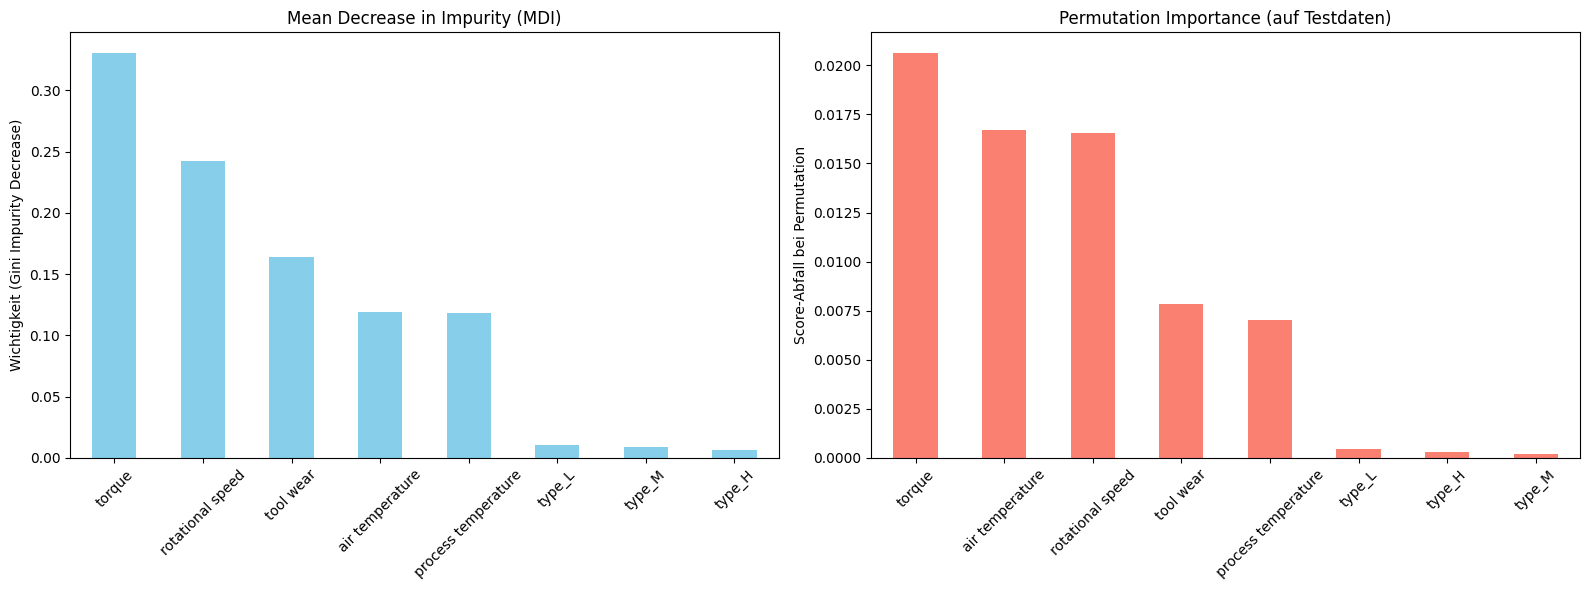

In [14]:
# ==============================================================================
# SCHRITT 8: MULTI-METHODEN FEATURE IMPORTANCE BEWERTUNG
# ==============================================================================

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import shap
import pandas as pd

# ------------------------------------------------------------------------------
# METHODE 1: Mean Decrease in Impurity (MDI)
# ------------------------------------------------------------------------------
# Dies ist die eingebaute Wichtigkeit von scikit-learn. Sie berechnet, wie stark
# jedes Feature im Durchschnitt zur Reduzierung der Gini-Unreinheit beiträgt.
# Wichtig: MDI neigt dazu, kontinuierliche Variablen mit hoher Varianz zu bevorzugen.
mdi_importances = best_rf.feature_importances_
mdi_series = pd.Series(mdi_importances, index=feature_cols).sort_values(ascending=False)

# ------------------------------------------------------------------------------
# METHODE 2: Permutation Importance (PI) auf Testdaten
# ------------------------------------------------------------------------------
# Bei dieser Methode werden die Werte eines Features auf den Testdaten zufällig durchgemischt.
# Die Differenz der Modell-Performance vor und nach dem Mischen spiegelt die Wichtigkeit wider.
# Vorteil: Da dies auf ungesehenen Testdaten geschieht, spiegelt es die echte Generalisierung wider.
perm_result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
perm_series = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

# ------------------------------------------------------------------------------
# METHODE 3: SHAP Values (Vorbereitung)
# ------------------------------------------------------------------------------
# SHAP basiert auf Spieltheorie (Shapley Values) und erklärt den Einfluss jedes Features
# additiv im Vergleich zu einer durchschnittlichen Baseline-Vorhersage.
# Wir verwenden TreeExplainer, der für baumbasierte Modelle stark optimiert ist.
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# ==============================================================================
# SCHRITT 9: VISUALISIERUNG DER KLASSISCHEN VERFAHREN (MDI vs. PI)
# ==============================================================================

# Erstellen einer vergleichenden Grafik mit zwei Subplots nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualisierung MDI (Linker Plot)
mdi_series.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Mean Decrease in Impurity (MDI)")
axes[0].set_ylabel("Wichtigkeit (Gini Impurity Decrease)")
axes[0].tick_params(axis='x', rotation=45)

# Visualisierung Permutation Importance (Rechter Plot)
perm_series.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("Permutation Importance (auf Testdaten)")
axes[1].set_ylabel("Score-Abfall bei Permutation")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

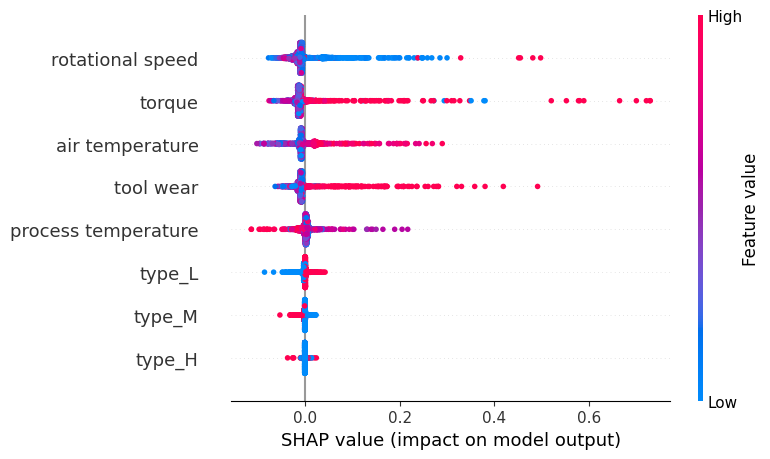

In [15]:
# ==============================================================================
# SCHRITT 10: VISUALISIERUNG DER SHAP-WERTE (GLOBALER & LOKALER EINFLUSS)
# ==============================================================================

# Der SHAP Summary Plot zeigt die Verteilung des Einflusses der einzelnen Variablen.
# Die Punkte repräsentieren einzelne Datenpunkte aus dem Testset.
# Die Farbe zeigt den Variablenwert (rot = hoch, blau = niedrig), die X-Achse den Einfluss auf die Entscheidung.

# Bei Binärklassifikation liefert shap_values oft eine Liste für beide Klassen (0: kein Ausfall, 1: Ausfall).
# Wir fokussieren uns explizit auf Klasse 1 (Maschinenausfall), um die Treiber zu verstehen.
if isinstance(shap_values, list):
    # Für ältere SHAP-Schnittstellen
    print("Visualisierung der SHAP Feature-Wichtigkeiten (Bar-Plot) für Klasse 1:")
    shap.summary_plot(shap_values[1], X_test, plot_type="bar")

    print("\nDetailed SHAP Summary-Plot (Einflussrichtung) für Klasse 1:")
    shap.summary_plot(shap_values[1], X_test)
else:
    # Für neuere SHAP-Schnittstellen (die z.B. direkt ein 3D-Array zurückgeben)
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], X_test)
    else:
        shap.summary_plot(shap_values, X_test)